# 07 - Estrategia: Agente Autónomo Multi-Estrategia

**Capítulo**: 07 - Agente Autónomo

**Objetivo**: Implementar detección de régimen, selector de estrategia y orquestador.

---

In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from curso.lib.data import download_historical
from curso.lib.indicators import sma, rsi, atr, bollinger_bands

plt.style.use('seaborn-v0_8-whitegrid')
print('Setup completado ✓')

Setup completado ✓


## 1. Detector de Régimen de Mercado

In [2]:
def compute_adx(df, period=14):
    """Calcula ADX (Average Directional Index) simplificado."""
    high, low, close = df['High'], df['Low'], df['Close']
    
    # True Range
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low - close.shift()).abs()
    ], axis=1).max(axis=1)
    
    # Directional Movement
    plus_dm = high.diff()
    minus_dm = -low.diff()
    plus_dm[plus_dm < 0] = 0
    minus_dm[minus_dm < 0] = 0
    
    # Smooth
    atr_val = tr.rolling(period).mean()
    plus_di = 100 * (plus_dm.rolling(period).mean() / atr_val)
    minus_di = 100 * (minus_dm.rolling(period).mean() / atr_val)
    
    # ADX
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    adx = dx.rolling(period).mean()
    
    return adx


def detect_regime(df, adx_threshold=25):
    """
    Detecta régimen de mercado.
    Returns: 'trending_up', 'trending_down', 'ranging', 'high_volatility'
    """
    adx = compute_adx(df).iloc[-1]
    sma_50 = sma(df, length=50).iloc[-1]
    sma_200 = sma(df, length=200).iloc[-1]
    atr_current = atr(df, length=14).iloc[-1]
    atr_mean = atr(df, length=14).mean()
    
    # High volatility check first
    if atr_current > 2 * atr_mean:
        return 'high_volatility'
    
    # Trending
    if adx > adx_threshold:
        if sma_50 > sma_200:
            return 'trending_up'
        else:
            return 'trending_down'
    
    return 'ranging'


# Test con SPY
spy = download_historical('SPY')
regime = detect_regime(spy)
print(f'Régimen actual de SPY: {regime}')

Régimen actual de SPY: trending_up


## 2. Selector de Estrategia

In [3]:
from backtesting import Strategy
from backtesting.test import SMA
from backtesting.lib import crossover


class SmaCrossStrategy(Strategy):
    """Para régimen trending_up (Cap 02)."""
    n1 = 10
    n2 = 20
    def init(self):
        self.sma1 = self.I(SMA, self.data.Close, self.n1)
        self.sma2 = self.I(SMA, self.data.Close, self.n2)
    def next(self):
        if crossover(self.sma1, self.sma2):
            self.buy()
        elif crossover(self.sma2, self.sma1):
            self.position.close()


class BollingerStrategy(Strategy):
    """Para régimen ranging (Cap 04)."""
    bb_period = 20
    bb_std = 2.0
    def init(self):
        close = pd.Series(self.data.Close)
        self.bb_mid = self.I(lambda c: pd.Series(c).rolling(self.bb_period).mean().values, self.data.Close)
        self.bb_low = self.I(lambda c: (pd.Series(c).rolling(self.bb_period).mean() - self.bb_std * pd.Series(c).rolling(self.bb_period).std()).values, self.data.Close)
    def next(self):
        if not self.position:
            if self.data.Close[-1] < self.bb_low[-1]:
                self.buy()
        else:
            if self.data.Close[-1] > self.bb_mid[-1]:
                self.position.close()


class CashStrategy(Strategy):
    """Para régimen trending_down o high_volatility."""
    def init(self):
        pass
    def next(self):
        pass  # No operar


STRATEGY_MAP = {
    'trending_up': SmaCrossStrategy,
    'trending_down': CashStrategy,
    'ranging': BollingerStrategy,
    'high_volatility': CashStrategy,
}

selected_strategy = STRATEGY_MAP[regime]
print(f'Régimen: {regime} → Estrategia: {selected_strategy.__name__}')

/Users/rolmov/Documents/github/sdd-project/.venv/lib/python3.12/site-packages/backtesting/_plotting.py:50: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support (e.g. PyCharm, Spyder IDE). Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

Régimen: trending_up → Estrategia: SmaCrossStrategy


/Users/rolmov/Documents/github/sdd-project/.venv/lib/python3.12/site-packages/backtesting/test/__init__.py:8: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.read_csv(join(dirname(__file__), filename),
/Users/rolmov/Documents/github/sdd-project/.venv/lib/python3.12/site-packages/backtesting/test/__init__.py:8: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.read_csv(join(dirname(__file__), filename),


## 3. Orquestador: Simulación de decisiones históricas


Historial de regímenes (48 puntos):
regime
trending_up      22
ranging          18
trending_down     8
Name: count, dtype: int64


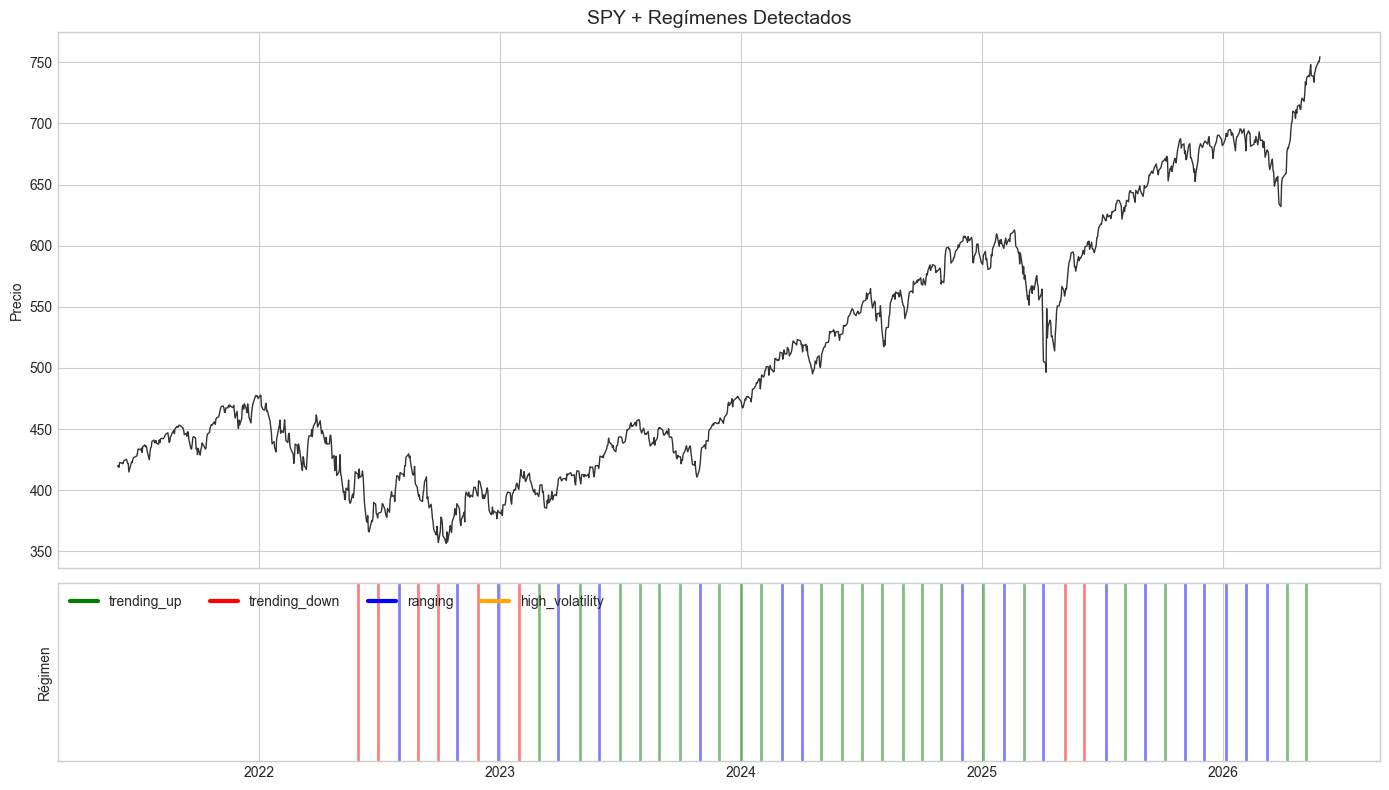

In [4]:
def simulate_regime_detection(df, window=252):
    """Detecta régimen en ventanas deslizantes."""
    regimes = []
    dates = df.index[window:]
    
    for i in range(window, len(df), 21):  # Check monthly
        subset = df.iloc[max(0, i-window):i]
        if len(subset) < 200:
            continue
        r = detect_regime(subset)
        regimes.append({'date': df.index[i], 'regime': r})
    
    return pd.DataFrame(regimes)

regime_history = simulate_regime_detection(spy)
print(f'\nHistorial de regímenes ({len(regime_history)} puntos):')
print(regime_history['regime'].value_counts())

# Visualizar regímenes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, height_ratios=[3, 1])

ax1.plot(spy.index, spy['Close'], color='#333', linewidth=1)
ax1.set_title('SPY + Regímenes Detectados', fontsize=14)
ax1.set_ylabel('Precio')

regime_colors = {'trending_up': 'green', 'trending_down': 'red', 'ranging': 'blue', 'high_volatility': 'orange'}
for _, row in regime_history.iterrows():
    ax2.axvline(row['date'], color=regime_colors.get(row['regime'], 'gray'), alpha=0.5, linewidth=2)

ax2.set_ylabel('Régimen')
ax2.set_yticks([])
# Legend
for regime_name, color in regime_colors.items():
    ax2.plot([], [], color=color, linewidth=3, label=regime_name)
ax2.legend(loc='upper left', ncol=4)

plt.tight_layout()
plt.show()

## Resumen

✅ Implementado detector de régimen (ADX + SMA)
✅ Mapeado regímenes a estrategias
✅ Simulada detección histórica
✅ Visualizados regímenes sobre precio

**Siguiente**: `07_backtesting.ipynb`